# Modelado y validación previa al proyecto modular

Este notebook documenta la etapa de **modelado previa** a la implementación final en módulos Python.

La idea es validar en notebook el mismo flujo que luego se organiza en el proyecto modular, especialmente en `src/train.py` y `src/evaluate.py`:

1. cargar el dataset limpio;
2. definir variables predictoras y variable objetivo;
3. dividir datos en entrenamiento y prueba;
4. construir un `Pipeline` de preprocesamiento y clasificación;
5. comparar modelos mediante `GridSearchCV` y validación cruzada estratificada;
6. seleccionar el mejor modelo usando `F1-score`;
7. evaluar el modelo final con `Accuracy`, `Precision`, `Recall` y `F1-score`.

Este notebook **no usa modo rápido ni muestreo**. Trabaja con el dataset completo, igual que el entrenamiento modular.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    make_scorer,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_SPLITS = 5

plt.rcParams["figure.figsize"] = (8, 4)

## 1. Carga del dataset limpio

El modelado se realiza sobre `data/processed/dataset_limpio.csv`, generado previamente por el proceso de limpieza.

En la secuencia del trabajo, primero se analiza el dataset en `exploracion.ipynb`, luego se usa este notebook para validar el entrenamiento y finalmente se lleva la lógica al proyecto modular.

In [2]:
def encontrar_raiz_proyecto():
    """Devuelve la raíz del proyecto, se ejecute el notebook desde notebooks/ o desde la raíz."""
    candidatos = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]

    for candidato in candidatos:
        dataset = candidato / "data" / "processed" / "dataset_limpio.csv"
        if dataset.exists():
            return candidato.resolve()

    raise FileNotFoundError(
        "No se encontró data/processed/dataset_limpio.csv. "
        "Ejecutá primero src/preprocessing.py o revisá la ubicación del notebook."
    )

BASE_DIR = encontrar_raiz_proyecto()
DATA_PATH = BASE_DIR / "data" / "processed" / "dataset_limpio.csv"
OUTPUTS_NOTEBOOK_DIR = BASE_DIR / "outputs" / "notebooks"
OUTPUTS_NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raíz del proyecto: {BASE_DIR}")
print(f"Dataset utilizado: {DATA_PATH}")
print(f"Carpeta de salida: {OUTPUTS_NOTEBOOK_DIR}")

Raíz del proyecto: C:\Users\Leo\Desktop\Proyecto-Final-Control-C
Dataset utilizado: C:\Users\Leo\Desktop\Proyecto-Final-Control-C\data\processed\dataset_limpio.csv
Carpeta de salida: C:\Users\Leo\Desktop\Proyecto-Final-Control-C\outputs\notebooks


In [3]:
df = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
df.head()

Filas: 75,193
Columnas: 8


,anio,edad_victima,sexo_victima,modo_desplazamiento_victima,rol_victima,mes,dia_semana,fatal
0,2019,25.0,F,BICICLETA,CICLISTA,1,4,0
1,2019,16.0,F,BICICLETA,CICLISTA,2,4,0
2,2019,32.0,F,BICICLETA,CICLISTA,3,2,0
3,2019,35.0,F,BICICLETA,CICLISTA,4,6,0
4,2019,42.0,F,BICICLETA,CICLISTA,5,1,0


## 2. Definición de variables

Se usan las mismas variables que luego se implementan en `src/config.py`:

- Variable objetivo: `fatal`
- Variables numéricas: `anio`, `edad_victima`, `mes`, `dia_semana`
- Variables categóricas: `sexo_victima`, `modo_desplazamiento_victima`, `rol_victima`

In [4]:
TARGET_COLUMN = "fatal"

NUMERIC_FEATURES = ["anio", "edad_victima", "mes", "dia_semana"]

CATEGORICAL_FEATURES = [
    "sexo_victima",
    "modo_desplazamiento_victima",
    "rol_victima",
]

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

columnas_requeridas = FEATURES + [TARGET_COLUMN]
columnas_faltantes = [col for col in columnas_requeridas if col not in df.columns]

if columnas_faltantes:
    raise ValueError(f"Faltan columnas requeridas: {columnas_faltantes}")

X = df[FEATURES].copy()
y = df[TARGET_COLUMN].copy()

print("Variables predictoras:")
print(FEATURES)
print("Variable objetivo:", TARGET_COLUMN)

Variables predictoras:
['anio', 'edad_victima', 'mes', 'dia_semana', 'sexo_victima', 'modo_desplazamiento_victima', 'rol_victima']
Variable objetivo: fatal


In [6]:
resumen_clases = y.value_counts().sort_index().to_frame("cantidad")
resumen_clases["porcentaje"] = (y.value_counts(normalize=True).sort_index() * 100).round(4)
resumen_clases.index = resumen_clases.index.map({0: "No fatal (0)", 1: "Fatal (1)"})
resumen_clases

,cantidad,porcentaje
fatal,,
No fatal (0),74490,99.0651
Fatal (1),703,0.9349


**Interpretación:** el dataset está fuertemente desbalanceado. La clase fatal es minoritaria, por eso se utilizan modelos con `class_weight="balanced"` y se analizan métricas como `Precision`, `Recall` y `F1-score`, además de `Accuracy`.

## 3. División entrenamiento / prueba

Se separa un conjunto de prueba con `train_test_split`. Se usa `stratify=y` para conservar la proporción entre casos fatales y no fatales tanto en entrenamiento como en prueba.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print("Distribución en entrenamiento:")
display(y_train.value_counts(normalize=True).sort_index().rename("proporcion"))
print("Distribución en prueba:")
display(y_test.value_counts(normalize=True).sort_index().rename("proporcion"))

X_train: (60154, 7)
X_test: (15039, 7)
Distribución en entrenamiento:


fatal
0    0.990657
1    0.009343
Name: proporcion, dtype: float64

Distribución en prueba:


fatal
0    0.990624
1    0.009376
Name: proporcion, dtype: float64

## 4. Pipeline de preprocesamiento

Se construye un `ColumnTransformer` para aplicar transformaciones distintas según el tipo de variable:

- variables numéricas: imputación por media y estandarización con `StandardScaler`;
- variables categóricas: imputación por moda y codificación `OneHotEncoder`.

Aca primero se transforman los datos y despuès se entrena el modelo. 
Esto evita fuga de información porque las transformaciones se ajustan solamente con los datos de entrenamiento dentro del pipeline.

In [8]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUMERIC_FEATURES),
        ("cat", categorical_transformer, CATEGORICAL_FEATURES),
    ]
)

base_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]
)

base_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

## 5. Comparación de modelos con GridSearchCV

Se comparan los mismos modelos que luego se usan en `src/train.py`:

1. `LogisticRegression`
2. `RandomForestClassifier`

La comparación se realiza mediante `GridSearchCV` con `StratifiedKFold`. El criterio de selección final es `F1-score`, porque combina `Precision` y `Recall`, algo importante cuando la clase positiva es minoritaria.

In [9]:
# Configuración de validación cruzada y búsqueda de hiperparámetros
# Esto define cómo se va a dividir el conjunto de entrenamiento durante la validación cruzada.
# StratifiedKFold divide los datos en varias partes, llamadas folds, manteniendo la proporción de clases. 0 -> No fatal, 1 -> Fatal
# Como los accidentes fatales son minoría, conviene que cada fold mantenga una proporción parecida de fatales y no fatales, 
# por eso se usa StratifiedKFold en lugar de KFold.
# n_splits=CV_SPLITS indica que se van a crear 5 folds, es decir, se va a entrenar y evaluar el modelo 5 veces, 
# cada vez con un fold diferente como conjunto de validación y los otros 4 como conjunto de entrenamiento.
# shuffle=True asegura que los datos se mezclen antes de dividirlos en folds, lo que ayuda a obtener una evaluación más robusta.
# random_state=RANDOM_STATE garantiza que la división de los datos sea reproducible, es decir, que se obtengan los mismos folds cada vez que se ejecute el código.

cv_strategy = StratifiedKFold(
    n_splits=CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

# Definición de métricas para evaluación
# Accuracy mide la proporción de predicciones correctas sobre el total de casos. Es fácil de interpretar pero puede ser engañosa en casos de clases desbalanceadas, como es nuestro caso, porque un modelo que siempre predice la clase mayoritaria (no fatal) podría tener una alta accuracy sin ser realmente útil para identificar los casos fatales.
#   Precision mide la proporción de verdaderos positivos sobre el total de predicciones positivas. 
#   En nuestro caso, indica de las veces que el modelo predijo "fatal", cuántas veces acertó. 
#   Es importante para evaluar la capacidad del modelo para evitar falsos positivos, es decir, predecir un accidente como fatal cuando no lo es.
# Recall mide la proporción de verdaderos positivos sobre el total de casos positivos reales. 
#   En nuestro caso, indica de los accidentes que realmente fueron fatales, cuántos el modelo logró identificar correctamente. 
#   Es crucial para evaluar la capacidad del modelo para detectar los casos fatales, que es nuestro objetivo principal.
# F1-score es la media armónica entre precision y recall. Es una métrica útil para evaluar el rendimiento general del modelo, 
#   especialmente en casos de clases desbalanceadas, porque penaliza tanto los falsos positivos como los fals os negativos, 
#   proporcionando una visión más equilibrada del rendimiento del modelo.
# make_scorer Convierte una función de métrica de scikit-learn en un formato que GridSearchCV puede usar.
# zero_division=0 evita errores o warnings cuando una métrica no puede calcularse. 
#   Por ejemplo, si el modelo no predice ningún caso como "fatal", la precision no se puede calcular porque el denominador sería cero.



scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
}

# Para configurar parámetros internos de classifier, scikit-learn usa doble guion bajo
# classifier__C
# classifier__n_estimators
# classifier__max_depth

param_grid = [
    {
        "classifier": [
            LogisticRegression(max_iter=1000, class_weight="balanced")
        ],
        "classifier__C": [0.1, 1, 10],
    },
    {
        "classifier": [
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced",
                n_jobs=-1,# Le indica a Random Forest que use todos los núcleos disponibles del procesador para entrenar más rápido.
            )
        ],
        "classifier__n_estimators": [100], # Indica la cantidad de árboles del Random Forest.
        "classifier__max_depth": [None, 10], # Indica la profundidad máxima de los árboles. None significa que no hay límite, mientras que 10 limita la profundidad a 10 niveles, lo que puede ayudar a prevenir el sobreajuste.
    },
]

# Esto crea el objeto que va a hacer la comparación de modelos.
# Todavía no entrena en esta línea. Solamente queda configurado.

grid_search = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring=scoring,
    refit="f1",
    n_jobs=1,
    return_train_score=True,
    error_score="raise",
)

print("Configuración de validación cruzada:")
print(f"Método: StratifiedKFold")
print(f"Folds: {CV_SPLITS}")
print(f"Métrica de selección: F1-score")
print("Modelos comparados: Regresión Logística y Random Forest")

Configuración de validación cruzada:
Método: StratifiedKFold
Folds: 5
Métrica de selección: F1-score
Modelos comparados: Regresión Logística y Random Forest


### Entrenamiento

La siguiente celda ejecuta el entrenamiento completo sobre el dataset completo. Puede tardar varios minutos porque realiza validación cruzada y búsqueda de hiperparámetros.

In [10]:
grid_search.fit(X_train, y_train)

print("Entrenamiento finalizado.")
print("Mejor modelo:", type(grid_search.best_estimator_.named_steps["classifier"]).__name__)
print("Mejores parámetros:", grid_search.best_params_)
print("Mejor F1 promedio en validación cruzada:", round(grid_search.best_score_, 4))

Entrenamiento finalizado.
Mejor modelo: RandomForestClassifier
Mejores parámetros: {'classifier': RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42), 'classifier__max_depth': None, 'classifier__n_estimators': 100}
Mejor F1 promedio en validación cruzada: 0.5842


## 6. Resultados de validación cruzada

Se resumen las métricas promedio obtenidas por cada combinación de modelo e hiperparámetros.

In [43]:
cv_results = pd.DataFrame(grid_search.cv_results_)

columnas_cv = [
    "param_classifier",
    "param_classifier__C",
    "param_classifier__n_estimators",
    "param_classifier__max_depth",
    "mean_test_accuracy",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1",
    "std_test_f1",
    "rank_test_f1",
]

columnas_existentes = [col for col in columnas_cv if col in cv_results.columns]
cv_resumen = cv_results[columnas_existentes].copy()

for col in cv_resumen.columns:
    if col.startswith("param_"):
        cv_resumen[col] = cv_resumen[col].astype(str)

cv_resumen = cv_resumen.sort_values("rank_test_f1")
cv_resumen.round(4)

,param_classifier,param_classifier__C,param_classifier__n_estimators,param_classifier__max_depth,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,std_test_f1,rank_test_f1
3,RandomForestClassifier(class_weight='balanced'...,NaN,100.0,NaN,0.9947,0.8559,0.5250,0.6484,0.0337,1
4,RandomForestClassifier(class_weight='balanced'...,NaN,100.0,10,0.9545,0.1438,0.7794,0.2428,0.0115,2
2,"LogisticRegression(class_weight='balanced', ma...",10.0,NaN,NaN,0.8709,0.0648,0.9537,0.1213,0.0018,3
1,"LogisticRegression(class_weight='balanced', ma...",1.0,NaN,NaN,0.8707,0.0647,0.9537,0.1212,0.0018,4
0,"LogisticRegression(class_weight='balanced', ma...",0.1,NaN,NaN,0.8691,0.0640,0.9537,0.1199,0.0019,5


In [33]:
cv_results_path = OUTPUTS_NOTEBOOK_DIR / "cv_modelado_train_equivalente.csv"
cv_resumen.to_csv(cv_results_path, index=False)
print(f"Resultados de validación cruzada guardados en: {cv_results_path}")

Resultados de validación cruzada guardados en: C:\Users\Leo\Desktop\Proyecto-Final-Control-C\outputs\notebooks\cv_modelado_train_equivalente.csv


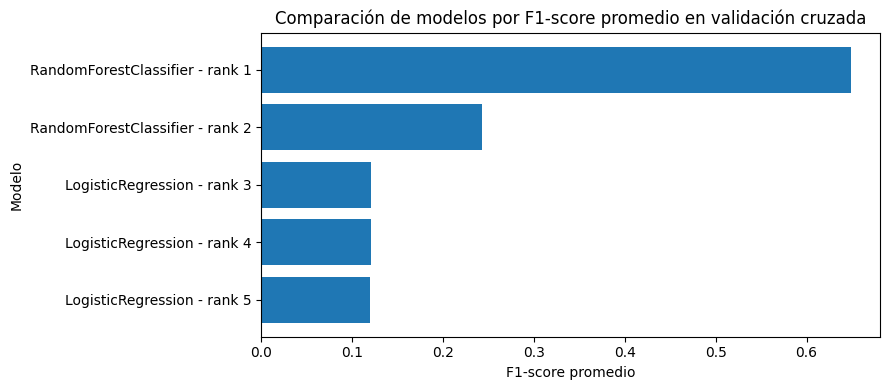

In [44]:
grafico_cv = cv_resumen.copy()
grafico_cv["modelo"] = grafico_cv["param_classifier"].str.extract(r"(LogisticRegression|RandomForestClassifier)")
grafico_cv["descripcion"] = grafico_cv["modelo"].fillna("Modelo") + " - rank " + grafico_cv["rank_test_f1"].astype(str)

grafico_cv = grafico_cv.sort_values("mean_test_f1", ascending=True)

plt.figure(figsize=(9, 4))
plt.barh(grafico_cv["descripcion"], grafico_cv["mean_test_f1"])
plt.title("Comparación de modelos por F1-score promedio en validación cruzada")
plt.xlabel("F1-score promedio")
plt.ylabel("Modelo")
plt.tight_layout()
plt.show()

## 7. Evaluación del mejor modelo en el conjunto de prueba

Después de seleccionar el mejor modelo mediante validación cruzada, se evalúa sobre `X_test`, que no fue usado para ajustar el modelo.

In [45]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

if hasattr(best_model.named_steps["classifier"], "predict_proba"):
    y_proba = best_model.predict_proba(X_test)[:, 1]
else:
    y_proba = None

metricas_test = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1_score": f1_score(y_test, y_pred, zero_division=0),
}

pd.DataFrame([metricas_test]).round(4)

,accuracy,precision,recall,f1_score
0,0.9951,0.8778,0.5603,0.684


In [46]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14898
           1       0.88      0.56      0.68       141

    accuracy                           1.00     15039
   macro avg       0.94      0.78      0.84     15039
weighted avg       0.99      1.00      0.99     15039



In [47]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Real no fatal (0)", "Real fatal (1)"],
    columns=["Pred. no fatal (0)", "Pred. fatal (1)"],
)
cm_df

,Pred. no fatal (0),Pred. fatal (1)
Real no fatal (0),14887,11
Real fatal (1),62,79


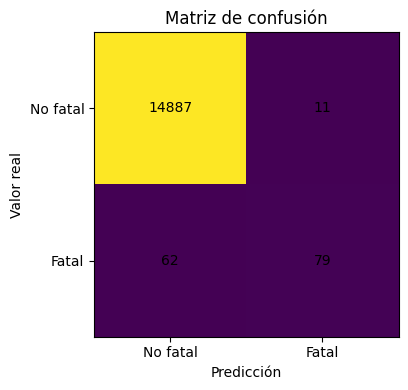

In [48]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["No fatal", "Fatal"])
ax.set_yticklabels(["No fatal", "Fatal"])
ax.set_xlabel("Predicción")
ax.set_ylabel("Valor real")
ax.set_title("Matriz de confusión")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## 8. Curva Precision-Recall

La curva Precision-Recall ayuda a analizar el comportamiento del modelo sobre la clase positiva `fatal=1`, especialmente porque es una clase minoritaria.

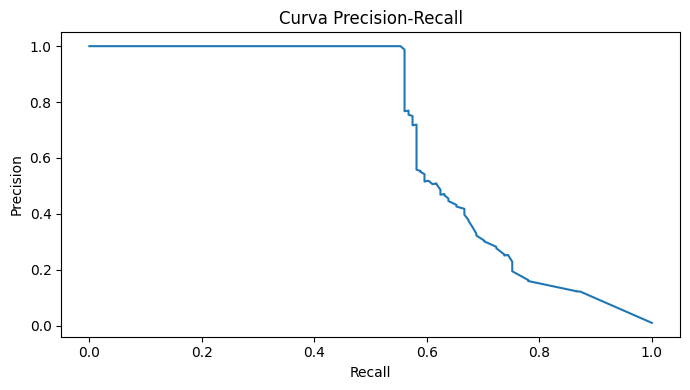

In [49]:
if y_proba is not None:
    precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, y_proba)

    plt.figure(figsize=(7, 4))
    plt.plot(recall_curve, precision_curve)
    plt.title("Curva Precision-Recall")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.tight_layout()
    plt.show()
else:
    print("El modelo no permite calcular probabilidades con predict_proba.")

## 9. Importancia de variables o coeficientes

Si el mejor modelo es Random Forest, se muestran las variables más importantes. Si el mejor modelo es Regresión Logística, se muestran los coeficientes de mayor magnitud absoluta.

,variable,importancia
27,cat__rol_victima_PEATON,0.251301
1,num__edad_victima,0.150358
14,cat__modo_desplazamiento_victima_PEATON,0.125068
24,cat__rol_victima_CONDUCTOR,0.108230
11,cat__modo_desplazamiento_victima_MOTO,0.065586
2,num__mes,0.060114
0,num__anio,0.058164
3,num__dia_semana,0.042354
26,cat__rol_victima_PASAJERO,0.030441
29,cat__rol_victima_conductor,0.022763


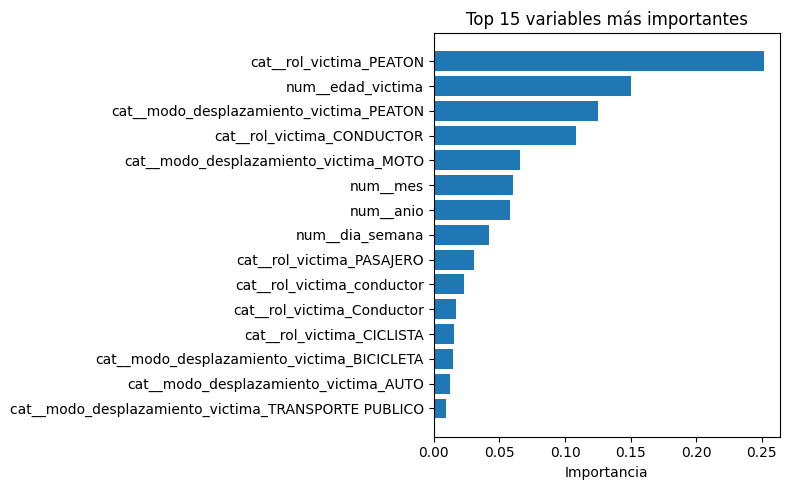

In [50]:
classifier = best_model.named_steps["classifier"]
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

if hasattr(classifier, "feature_importances_"):
    importancia = pd.DataFrame({
        "variable": feature_names,
        "importancia": classifier.feature_importances_,
    }).sort_values("importancia", ascending=False)

    display(importancia.head(15))

    top_importancia = importancia.head(15).sort_values("importancia", ascending=True)
    plt.figure(figsize=(8, 5))
    plt.barh(top_importancia["variable"], top_importancia["importancia"])
    plt.title("Top 15 variables más importantes")
    plt.xlabel("Importancia")
    plt.tight_layout()
    plt.show()

elif hasattr(classifier, "coef_"):
    coeficientes = pd.DataFrame({
        "variable": feature_names,
        "coeficiente": classifier.coef_[0],
    })
    coeficientes["abs_coeficiente"] = coeficientes["coeficiente"].abs()
    coeficientes = coeficientes.sort_values("abs_coeficiente", ascending=False)

    display(coeficientes.head(15))

    top_coef = coeficientes.head(15).sort_values("abs_coeficiente", ascending=True)
    plt.figure(figsize=(8, 5))
    plt.barh(top_coef["variable"], top_coef["coeficiente"])
    plt.title("Top 15 coeficientes de mayor magnitud")
    plt.xlabel("Coeficiente")
    plt.tight_layout()
    plt.show()

else:
    print("El modelo seleccionado no expone importancias ni coeficientes.")

## 10. Guardado de resultados del notebook

Se guardan métricas, resultados de validación cruzada y predicciones para poder comparar lo obtenido en notebook con lo que luego genera el proyecto modular.

In [51]:
metricas_path = OUTPUTS_NOTEBOOK_DIR / "metricas_modelado_train_equivalente.json"
predicciones_path = OUTPUTS_NOTEBOOK_DIR / "predicciones_modelado_train_equivalente.csv"

best_params_serializable = {}
for key, value in grid_search.best_params_.items():
    if key == "classifier":
        best_params_serializable[key] = type(value).__name__
    else:
        best_params_serializable[key] = value

metricas_export = {
    **{k: float(v) for k, v in metricas_test.items()},
    "best_cv_f1": float(grid_search.best_score_),
    "best_params": best_params_serializable,
    "cv_splits": int(CV_SPLITS),
    "test_size": float(TEST_SIZE),
    "random_state": int(RANDOM_STATE),
    "dataset_completo": True,
    "cantidad_filas": int(len(df)),
}

with open(metricas_path, "w", encoding="utf-8") as f:
    json.dump(metricas_export, f, indent=4, ensure_ascii=False)

predicciones = X_test.copy()
predicciones["fatal_real"] = y_test.values
predicciones["fatal_predicho"] = y_pred
if y_proba is not None:
    predicciones["probabilidad_fatal"] = y_proba

predicciones.to_csv(predicciones_path, index=False)

print(f"Métricas guardadas en: {metricas_path}")
print(f"Predicciones guardadas en: {predicciones_path}")

Métricas guardadas en: C:\Users\Leo\Desktop\Proyecto-Final-Control-C\outputs\notebooks\metricas_modelado_train_equivalente.json
Predicciones guardadas en: C:\Users\Leo\Desktop\Proyecto-Final-Control-C\outputs\notebooks\predicciones_modelado_train_equivalente.csv


## 11. Conclusiones del modelado en notebook

- Se validó el flujo completo de entrenamiento antes de llevarlo al proyecto modular.
- Se trabajó con el dataset completo.
- Se aplicó un pipeline con imputación, escalado, codificación One-Hot y clasificador.
- Se compararon Regresión Logística y Random Forest mediante `GridSearchCV`.
- Se usó `StratifiedKFold` para conservar la proporción de clases en cada fold.
- Se seleccionó el mejor modelo según `F1-score`, métrica adecuada para un problema con fuerte desbalance de clases.
- El código validado en este notebook puede trasladarse de forma directa a `src/train.py` para dejar el proyecto ordenado, automatizado y reproducible.